## Section 0 — Setup: libraries, seeds, and dataset paths

In [1]:
import subprocess, sys

def _pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=False)

try:
    import torch_geometric  # noqa
except Exception:
    _pip("torch_geometric")

import importlib
for _m in ["geopandas", "shapely", "pyarrow"]:
    try:
        importlib.import_module(_m)
    except Exception:
        _pip(_m)

print("Setup install step complete.")

# [local-run repair] `section()` is called in this notebook but never defined in it.
def section(t):
    print("\n" + "=" * 78 + f"\n{t}\n" + "=" * 78)


C:\Users\gauri\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup install step complete.


In [2]:
import os, glob, random, warnings, json, itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import geopandas as gpd
from shapely.geometry import Point

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import GATConv


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WORK = "/kaggle/working" if os.path.isdir("/kaggle") else os.path.abspath("../../outputs_v2/partA")
os.makedirs(WORK, exist_ok=True)


MAX_INTRA_GROUP_K = 8

print("torch:", torch.__version__, "| torch_geometric:", torch_geometric.__version__)
print("geopandas:", gpd.__version__, "| device:", DEVICE, "| SEED:", SEED)

# [local-run repair] `section()` is called in this notebook but never defined in it.
def section(t):
    print("\n" + "=" * 78 + f"\n{t}\n" + "=" * 78)


torch: 2.10.0+cpu | torch_geometric: 2.8.0.post1
geopandas: 1.1.4 | device: cpu | SEED: 42


In [3]:
section("A.0 -- checkpoint helper (WRITE to WORK only, READ from WORK then /kaggle/input)")

CKPT_DIR = os.path.join(WORK, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_VERSION = "v1"   # bump to invalidate every checkpoint at once

FORCE_RECOMPUTE = []   # e.g. ["gat_training"] to ignore those checkpoints regardless of cache state

CKPT_MANIFEST = []   # rows: {stage, name, kind, path, bytes, rows_or_shape, hit_or_miss}

def ckpt_path(name, ext):
    return os.path.join(CKPT_DIR, f"{name}__{CKPT_VERSION}.{ext}")

def _ckpt_search_input(name, ext):
    """Recursive search under /kaggle/input for a checkpoint file written by an earlier,
    chained notebook run (Kaggle's Add Data mechanism can place it at any depth)."""
    pattern = f"{name}__{CKPT_VERSION}.{ext}"
    hits = glob.glob(os.path.join("/kaggle/input", "**", pattern), recursive=True)
    return hits[0] if hits else None

def ckpt_find(name, ext):
    """WORK first (same-session or already-copied-back), then anywhere under /kaggle/input
    (a prior notebook's committed output, added as a data source). Returns a path or None."""
    work_p = ckpt_path(name, ext)
    if os.path.exists(work_p):
        return work_p
    return _ckpt_search_input(name, ext)

def _sidecar_path(path):
    return path + ".meta.json"

def ckpt_save(obj, name, kind, stage=None, staleness_keys=None):
    """kind in {'parquet','json','torch','csv'}. Writes to ckpt_path(), a staleness-key sidecar
    alongside it (A.3), prints the path and size, and appends a row to CKPT_MANIFEST."""
    ext = {"parquet": "parquet", "json": "json", "torch": "pt", "csv": "csv"}[kind]
    path = ckpt_path(name, ext)
    rows_or_shape = None
    if kind == "parquet":
        obj.to_parquet(path, index=False)
        rows_or_shape = f"{len(obj)} rows"
    elif kind == "csv":
        obj.to_csv(path, index=False)
        rows_or_shape = f"{len(obj)} rows"
    elif kind == "json":
        with open(path, "w") as fh:
            json.dump(obj, fh)
        rows_or_shape = f"{len(obj)} keys" if hasattr(obj, "__len__") else "n/a"
    elif kind == "torch":
        torch.save(obj, path)
        rows_or_shape = "torch object"
    else:
        raise ValueError(f"unknown ckpt kind: {kind}")

    if staleness_keys is not None:
        with open(_sidecar_path(path), "w") as fh:
            json.dump(staleness_keys, fh, default=str)

    size_bytes = os.path.getsize(path)
    CKPT_MANIFEST.append({
        "stage": stage or name, "name": name, "kind": kind, "path": path,
        "bytes": size_bytes, "rows_or_shape": rows_or_shape, "hit_or_miss": "MISS (just saved)",
    })
    print(f"[CKPT SAVE] {name} ({kind}) -> {path}  |  {size_bytes:,} bytes  |  {rows_or_shape}")
    return path

def ckpt_load(name, kind, validate=None, stage=None, staleness_keys=None):
    """Finds via ckpt_find, checks staleness_keys against the saved sidecar if given, loads, and
    runs validate(obj) if given. Returns None on miss, staleness mismatch, or failed validation,
    printing the reason each time. Never raises on a miss."""
    if name in FORCE_RECOMPUTE:
        print(f"[CKPT SKIP] {name}: listed in FORCE_RECOMPUTE -- ignoring any existing checkpoint.")
        return None
    ext = {"parquet": "parquet", "json": "json", "torch": "pt", "csv": "csv"}[kind]
    path = ckpt_find(name, ext)
    if path is None:
        print(f"[CKPT MISS -> computing] {name}: no checkpoint found in WORK or /kaggle/input.")
        return None

    if staleness_keys is not None:
        sidecar = _sidecar_path(path)
        if not os.path.exists(sidecar):
            print(f"[CKPT MISS -> computing] {name}: checkpoint found at {path} but has no staleness "
                  "sidecar to validate against -- treating as stale.")
            return None
        with open(sidecar) as fh:
            saved_keys = json.load(fh)
        mismatches = []
        for k, v in staleness_keys.items():
            saved_v = saved_keys.get(k, "<missing>")
            if str(saved_v) != str(v):
                mismatches.append((k, saved_v, v))
        if mismatches:
            detail = "; ".join(f"{k}: saved={sv!r} != current={cv!r}" for k, sv, cv in mismatches)
            print(f"[CKPT MISS -> computing] {name}: staleness key mismatch -- {detail}")
            return None

    try:
        if kind == "parquet":
            obj = pd.read_parquet(path)
        elif kind == "csv":
            obj = pd.read_csv(path)
        elif kind == "json":
            with open(path) as fh:
                obj = json.load(fh)
        elif kind == "torch":
            obj = torch.load(path, weights_only=False)
        else:
            raise ValueError(f"unknown ckpt kind: {kind}")
    except Exception as e:
        print(f"[CKPT MISS -> computing] {name}: failed to load {path} ({type(e).__name__}: {e}).")
        return None

    if validate is not None:
        try:
            ok = validate(obj)
        except Exception as e:
            print(f"[CKPT MISS -> computing] {name}: validate() raised {type(e).__name__}: {e}.")
            return None
        if not ok:
            print(f"[CKPT MISS -> computing] {name}: loaded but failed validate().")
            return None

    size_bytes = os.path.getsize(path)
    rows_or_shape = f"{len(obj)} rows" if hasattr(obj, "__len__") else "n/a"
    CKPT_MANIFEST.append({
        "stage": stage or name, "name": name, "kind": kind, "path": path,
        "bytes": size_bytes, "rows_or_shape": rows_or_shape, "hit_or_miss": "HIT",
    })
    print(f"[CKPT HIT] {name} ({kind}) <- {path}  |  {size_bytes:,} bytes  |  {rows_or_shape}")
    return obj

print(f"Checkpoint dir: {CKPT_DIR}  |  CKPT_VERSION={CKPT_VERSION}  |  FORCE_RECOMPUTE={FORCE_RECOMPUTE}")



A.0 -- checkpoint helper (WRITE to WORK only, READ from WORK then /kaggle/input)
Checkpoint dir: C:\Users\gauri\Projects\nexus\outputs_v2\partA\checkpoints  |  CKPT_VERSION=v1  |  FORCE_RECOMPUTE=[]


In [4]:

INCLUDE_TEMPERATURE = True
TEMP_BATCH_SIZE = 50
TEMP_PAUSE_SECONDS = 4.0
TEMP_MAX_RETRIES = 6
TEMP_COVERAGE_MIN = 0.80     

try:
    import requests, time as _time
    _REQUESTS_OK = True
except Exception:
    _REQUESTS_OK = False

def _openmeteo_current_temp(lats, lons):
    params = {"latitude": ",".join(f"{v:.4f}" for v in lats),
              "longitude": ",".join(f"{v:.4f}" for v in lons),
              "current": "temperature_2m", "timezone": "auto"}
    r = requests.get("https://api.open-meteo.com/v1/forecast", params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict):
        data = [data]
    return [e.get("current", {}).get("temperature_2m", np.nan) for e in data]

def fetch_current_temperature(lat_arr, lon_arr):
    '''Batched, retried Open-Meteo current-temperature fetch. Returns np.array aligned to inputs.'''
    if not _REQUESTS_OK:
        return np.full(len(lat_arr), np.nan)
    out = []
    n_b = len(range(0, len(lat_arr), TEMP_BATCH_SIZE))
    for bi, start in enumerate(range(0, len(lat_arr), TEMP_BATCH_SIZE)):
        bl = lat_arr[start:start + TEMP_BATCH_SIZE]; bo = lon_arr[start:start + TEMP_BATCH_SIZE]
        delay = TEMP_PAUSE_SECONDS; got = None
        for _ in range(TEMP_MAX_RETRIES):
            try:
                res = _openmeteo_current_temp(bl, bo)
                if len(res) != len(bl):
                    raise ValueError("batch length mismatch")
                got = res; break
            except requests.exceptions.HTTPError as e:
                st = e.response.status_code if e.response is not None else None
                if st in (429, 503):
                    _time.sleep(delay); delay *= 2
                else:
                    break
            except Exception:
                break
        out.extend(got if got is not None else [np.nan] * len(bl))
        _time.sleep(TEMP_PAUSE_SECONDS)
        if (bi + 1) % 10 == 0:
            print(f"    ...temperature {bi + 1}/{n_b} batches")
    return np.asarray(out, dtype=float)

print("Temperature fetch ready | INCLUDE_TEMPERATURE =", INCLUDE_TEMPERATURE, "| requests available:", _REQUESTS_OK)

Temperature fetch ready | INCLUDE_TEMPERATURE = True | requests available: True


## Step 0 

In [5]:

INPUT_ROOT = "/kaggle/input" if os.path.isdir("/kaggle/input") else os.path.abspath("../../data")

KNOWN = {
    "datacenters_parquet": "/kaggle/input/datasets/energyclimaterp/datacenter/datacenters.parquet",
    "ember_us":  "/kaggle/input/datasets/energyclimaterp/us-monthly-ember-electricity/us_monthly_full_release_long_format.csv",
    "ember_india": "/kaggle/input/datasets/energyclimaterp/india-ember-energy-monthly-electricity/india_monthly_full_release_long_format (1).csv",
    "aqueduct_gdb": "/kaggle/input/datasets/energyclimaterp/water-risk-aqueduct/Aqueduct40_waterrisk_download_Y2023M07D05/GDB/Aq40_Y2023D07M05.gdb",
}

def _walk_find(pred):
    if not os.path.isdir(INPUT_ROOT):
        return None
    for root, dirs, files in os.walk(INPUT_ROOT):
        for f in files:
            p = os.path.join(root, f)
            if pred(p):
                return p
        for d in dirs:  # for the .gdb, which is a directory
            p = os.path.join(root, d)
            if pred(p):
                return p
    return None

def resolve(key, fallback_pred):
    p = KNOWN.get(key)
    if p and os.path.exists(p):
        return p
    return _walk_find(fallback_pred)

paths = {}
paths["datacenters_parquet"] = resolve("datacenters_parquet",
        lambda p: p.lower().endswith("datacenters.parquet"))
paths["ember_us"] = resolve("ember_us",
        lambda p: p.lower().endswith(".csv") and "us_monthly" in os.path.basename(p).lower())
paths["ember_eu"] = _walk_find(
        lambda p: p.lower().endswith(".csv") and "europe_monthly" in os.path.basename(p).lower())
paths["ember_india"] = resolve("ember_india",
        lambda p: p.lower().endswith(".csv") and "india_monthly" in os.path.basename(p).lower())
paths["aqueduct_gdb"] = resolve("aqueduct_gdb",
        lambda p: p.lower().endswith(".gdb"))
# raw datacenter CSV (for the discrepancy report only) and G3P (inspection only)
paths["datacenters_csv"] = _walk_find(
        lambda p: os.path.basename(p).lower().startswith("datacenters") and p.lower().endswith(".csv"))
paths["g3p_dir"] = _walk_find(lambda p: os.path.isdir(p) and "groundwater" in p.lower()) \
        or _walk_find(lambda p: "G3P_v1.12" in os.path.basename(p))

print("Resolved input paths:")
for k, v in paths.items():
    tick = "OK " if (v and os.path.exists(v)) else "!! "
    print(f"  [{tick}] {k:20s} -> {v}")

Resolved input paths:
  [OK ] datacenters_parquet  -> C:\Users\gauri\Projects\nexus\data\datacenters.parquet
  [OK ] ember_us             -> C:\Users\gauri\Projects\nexus\data\ember\us_monthly_full_release_long_format.csv
  [OK ] ember_eu             -> C:\Users\gauri\Projects\nexus\data\ember\europe_monthly_full_release_long_format.csv
  [OK ] ember_india          -> C:\Users\gauri\Projects\nexus\data\ember\india_monthly_full_release_long_format.csv
  [OK ] aqueduct_gdb         -> C:\Users\gauri\Projects\nexus\data\aqueduct\Aqueduct40_waterrisk_download_Y2023M07D05\GDB\Aq40_Y2023D07M05.gdb
  [!! ] datacenters_csv      -> None
  [OK ] g3p_dir              -> C:\Users\gauri\Projects\nexus\data\g3p\G3P_v1.12_tws_rivbas.csv


In [6]:

REQUIRED = ["datacenters_parquet", "ember_us", "ember_eu", "ember_india", "aqueduct_gdb"]
missing = [k for k in REQUIRED if not (paths.get(k) and os.path.exists(paths[k]))]
if missing:
    msg = ("STOP — required input(s) missing from /kaggle/input: " + ", ".join(missing) +
           "\nThe notebook will not fabricate or substitute a source. "
           "Attach the `energyclimaterp` dataset (or fix the paths above) and re-run.")
    raise FileNotFoundError(msg)
print("All required inputs located. Proceeding to inspection.")

# Note the datacenters (1).csv discrepancy explicitly (assumption A1).
if paths.get("datacenters_csv"):
    _c = pd.read_csv(paths["datacenters_csv"], nrows=5)
    print("\n[A1] Raw 'datacenters (1).csv' columns:", list(_c.columns))
    has_coords = any(c.lower() in ("latitude", "longitude", "lat", "lon") for c in _c.columns)
    print(f"[A1] Raw CSV contains coordinates? {has_coords} "
          f"-> using datacenters.parquet for geocoding instead (see assumption A1).")

All required inputs located. Proceeding to inspection.


In [7]:

def inspect_csv(path, name, nrows=5):
    print(f"\n===== {name} =====\n{path}")
    df = pd.read_csv(path, nrows=nrows)
    # get true row count cheaply for the big files
    print("head shape:", df.shape, "| columns:", list(df.columns))
    print("dtypes:\n", df.dtypes.to_string())
    print("head:\n", df.head(3).to_string()[:1200])
    return df

_ = inspect_csv(paths["ember_us"], "EMBER — United States (monthly long format)")
_ = inspect_csv(paths["ember_eu"], "EMBER — Europe (monthly long format)")
_ = inspect_csv(paths["ember_india"], "EMBER — India (monthly long format)")

print("\n===== Datacenter Atlas (parquet) =====\n", paths["datacenters_parquet"])
dc_head = pd.read_parquet(paths["datacenters_parquet"])
print("shape:", dc_head.shape, "| columns:", list(dc_head.columns))
print("dtypes:\n", dc_head.dtypes.to_string())
print("head:\n", dc_head.head(3).to_string()[:1200])
coord_cols = [c for c in dc_head.columns if c.lower() in ("latitude", "longitude", "lat", "lon")]
print("[A1] coordinate columns present in parquet:", coord_cols)
assert coord_cols, "Datacenter parquet has no coordinate columns — cannot geocode. STOP."


===== EMBER — United States (monthly long format) =====
C:\Users\gauri\Projects\nexus\data\ember\us_monthly_full_release_long_format.csv
head shape: (5, 13) | columns: ['Country', 'Country code', 'State', 'State code', 'State type', 'Date', 'Category', 'Subcategory', 'Variable', 'Unit', 'Value', 'YoY absolute change', 'YoY % change']
dtypes:
 Country                    str
Country code               str
State                      str
State code                 str
State type                 str
Date                       str
Category                   str
Subcategory                str
Variable                   str
Unit                       str
Value                  float64
YoY absolute change    float64
YoY % change           float64
head:
                     Country Country code    State State code State type        Date                Category     Subcategory              Variable Unit  Value  YoY absolute change  YoY % change
0  United States of America          USA  Alabama  

In [8]:

print("===== Aqueduct 4.0 GDB =====\n", paths["aqueduct_gdb"])
aq_cols_needed = ["pfaf_id", "gid_0", "name_0", "name_1", "bws_score", "geometry"]
gdf_aq = gpd.read_file(paths["aqueduct_gdb"])
print("full GDB shape:", gdf_aq.shape)
print("has required cols:", [c for c in aq_cols_needed if c in gdf_aq.columns])
missing_aq = [c for c in aq_cols_needed if c not in gdf_aq.columns]
if missing_aq:
    raise KeyError(f"STOP — Aqueduct GDB missing expected columns {missing_aq}. Present: {list(gdf_aq.columns)[:40]}")
print("CRS:", gdf_aq.crs)
print("head (attrs):\n", gdf_aq[["pfaf_id", "gid_0", "name_0", "name_1", "bws_score"]].head(3).to_string())

# G3P water storage: inspection only (assumption A6 — NOT used as a node feature).
if paths.get("g3p_dir"):
    g3p_files = glob.glob(os.path.join(paths["g3p_dir"], "*.csv")) if os.path.isdir(paths["g3p_dir"]) else [paths["g3p_dir"]]
    print(f"\n[A6] G3P water-storage files found: {len(g3p_files)} (inspected, NOT used as node features).")
    if g3p_files:
        g = pd.read_csv(g3p_files[0], nrows=3)
        print("    example:", os.path.basename(g3p_files[0]), "| cols[:6]:", list(g.columns)[:6],
              "| keyed by river-basin NAME, not pfaf_id -> excluded from feature vector.")
else:
    print("\n[A6] No G3P water-storage folder located — nothing to exclude.")

# ---- [A2] Temperature source: a LIVE Open-Meteo fetch per datacenter lat/lon (not a file). ----
# (Per nbs/global-datacenter-temperature-overlay.ipynb the temperature is fetched live, not stored
#  in /kaggle/input, so we also report whether any temperature FILE happens to exist for the record.)
temp_hits = _walk_find(lambda p: any(t in os.path.basename(p).lower()
                       for t in ["temperature", "temp_", "_temp", "era5", "climate_temp"]))
print(f"\n[A2] Temperature FILE present in /kaggle/input? {'YES: '+temp_hits if temp_hits else 'NO'}")
print(f"[A2] Temperature SOURCE = live Open-Meteo 'current' reading per site (INCLUDE_TEMPERATURE={INCLUDE_TEMPERATURE}).")
print("[A2] -> Node features will INCLUDE temperature as a static per-site snapshot IF the fetch succeeds")
print("[A2]    (>= %.0f%% coverage); otherwise it is omitted and reported (never fabricated)." % (100*TEMP_COVERAGE_MIN))

===== Aqueduct 4.0 GDB =====
 C:\Users\gauri\Projects\nexus\data\aqueduct\Aqueduct40_waterrisk_download_Y2023M07D05\GDB\Aq40_Y2023D07M05.gdb


full GDB shape: (68506, 237)
has required cols: ['pfaf_id', 'gid_0', 'name_0', 'name_1', 'bws_score', 'geometry']
CRS: EPSG:4326
head (attrs):
    pfaf_id gid_0 name_0      name_1  bws_score
0   111011   EGY  Egypt  Al Qahirah        5.0
1   111011   EGY  Egypt   As Suways        5.0
2   111011   EGY  Egypt   As Suways        5.0

[A6] G3P water-storage files found: 1 (inspected, NOT used as node features).
    example: G3P_v1.12_tws_rivbas.csv | cols[:6]: ['time [yyyy_doy]', 'time [yyyy-mm-dd]', 'global [mm]', 'uncertainty_global [mm]', 'Albany River [mm]', 'uncertainty_Albany River [mm]'] | keyed by river-basin NAME, not pfaf_id -> excluded from feature vector.

[A2] Temperature FILE present in /kaggle/input? NO
[A2] Temperature SOURCE = live Open-Meteo 'current' reading per site (INCLUDE_TEMPERATURE=True).
[A2] -> Node features will INCLUDE temperature as a static per-site snapshot IF the fetch succeeds
[A2]    (>= 80% coverage); otherwise it is omitted and reported (never fabricate

## Step 1 — Spatial + temporal alignment

### 1a. Determine actual temporal coverage and the coarsest common granularity

We read the `Date` column of each EMBER release directly and check (i) its real min/max range and (ii) its real
granularity (the spacing between consecutive dates) — we do **not** assume "monthly". Aqueduct is a **static**
per-basin snapshot (no time axis), so it does not enter the temporal-resolution decision.

In [9]:
def coverage(path, date_col, region):
    d = pd.read_csv(path, usecols=[date_col])
    dt = pd.to_datetime(d[date_col], errors="coerce").dropna().sort_values().unique()
    dt = pd.DatetimeIndex(dt)
    # modal spacing between consecutive distinct dates
    diffs = pd.Series(dt).diff().dropna().dt.days
    modal = int(diffs.mode().iloc[0]) if len(diffs) else np.nan
    gran = "monthly" if 28 <= modal <= 31 else ("daily" if modal == 1 else f"{modal}d")
    print(f"{region:8s} range {dt.min().date()} .. {dt.max().date()} | "
          f"n_distinct_dates={len(dt)} | modal spacing={modal}d -> {gran}")
    return dt.min(), dt.max(), gran

print("Temporal coverage per EMBER release (verified from the data, not assumed):")
cov = {}
cov["US"]    = coverage(paths["ember_us"],    "Date", "US")
cov["EU"]    = coverage(paths["ember_eu"],    "Date", "EU")
cov["India"] = coverage(paths["ember_india"], "Date", "India")

grans = {v[2] for v in cov.values()}
common_start = max(v[0] for v in cov.values())
common_end   = min(v[1] for v in cov.values())
print("\nGranularities observed:", grans)
COARSEST = "monthly" if grans == {"monthly"} else "monthly"  # all monthly here; guarded below
assert grans == {"monthly"}, f"Unexpected non-monthly granularity: {grans} — revisit resampling logic."
print(f"Coarsest common granularity  : {COARSEST}  (all three releases are monthly)")
print(f"Common overlapping window    : {common_start.date()} .. {common_end.date()} "
      f"(driven by the shortest release — India, which starts {cov['India'][0].date()})")

Temporal coverage per EMBER release (verified from the data, not assumed):


US       range 2001-01-01 .. 2025-12-01 | n_distinct_dates=300 | modal spacing=31d -> monthly
EU       range 2010-01-01 .. 2026-04-01 | n_distinct_dates=196 | modal spacing=31d -> monthly


India    range 2019-01-01 .. 2025-11-01 | n_distinct_dates=83 | modal spacing=31d -> monthly

Granularities observed: {'monthly'}
Coarsest common granularity  : monthly  (all three releases are monthly)
Common overlapping window    : 2019-01-01 .. 2025-11-01 (driven by the shortest release — India, which starts 2019-01-01)


**Reasoning (printed above, restated here):** all three EMBER releases are already **monthly**, so the coarsest
common granularity is **monthly** — no down-sampling of a finer series is required. The common overlapping window is
bounded below by India's start date. All time-varying features below are restricted to this window, and the
**as-of feature snapshot uses only months ≤ the window end** (temporal-leakage guard, applied in Step 1c).

### 1b. Build the EMBER zone panel (electricity + carbon per grid zone per month)

**Definition of "electricity grid zone" (assumption A3), stated explicitly:**
- **US rows** → `USA|<state>` (EMBER `State`, sub-national)
- **India rows** → `IND|<state>` (EMBER `State`, sub-national)
- **Europe rows** → `<ISO3>` (EMBER `ISO 3 code`, national)

**Channels (assumption A5):** `electricity_gwh` = `Total generation` (EU `TWh`×1000 → `GWh`); `co2_intensity` =
`CO2 intensity` (gCO₂/kWh). These are the only two quantities present and comparable across **all three** releases.

In [10]:
def _norm(s):
    return (str(s).strip().lower()
            .replace("&", "and").replace(".", "").replace(",", "")
            .replace("  ", " "))

def load_ember_region(path, region):
    # Columns differ: US/India have State; EU has Area + ISO 3 code + Area type.
    cols = pd.read_csv(path, nrows=0).columns.tolist()
    usecols = [c for c in ["State", "State code", "Area", "ISO 3 code", "Area type",
                           "Date", "Category", "Variable", "Unit", "Value"] if c in cols]
    df = pd.read_csv(path, usecols=usecols)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    gen = df[(df["Category"] == "Electricity generation") &
             (df["Variable"].str.lower() == "total generation") &
             (df["Unit"].isin(["GWh", "TWh"]))].copy()
    # unit-normalise to GWh
    gen["electricity_gwh"] = np.where(gen["Unit"] == "TWh", gen["Value"] * 1000.0, gen["Value"])

    car = df[(df["Category"] == "Power sector emissions") &
             (df["Variable"] == "CO2 intensity")].copy()
    car["co2_intensity"] = car["Value"]

    if region in ("US", "India"):
        iso = "USA" if region == "US" else "IND"
        for g in (gen, car):
            g["zone_id"] = iso + "|" + g["State"].map(_norm)
            # drop national aggregates like "India Total"
            g.drop(g.index[g["State"].astype(str).str.lower().str.contains("total")], inplace=True)
    else:  # EU
        gen = gen[gen["Area type"] == "Country or economy"]
        car = car[car["Area type"] == "Country or economy"]
        gen["zone_id"] = gen["ISO 3 code"].astype(str)
        car["zone_id"] = car["ISO 3 code"].astype(str)

    gen = gen.dropna(subset=["Value", "zone_id", "Date"])
    car = car.dropna(subset=["Value", "zone_id", "Date"])
    g = gen.groupby(["zone_id", "Date"], as_index=False)["electricity_gwh"].mean()
    c = car.groupby(["zone_id", "Date"], as_index=False)["co2_intensity"].mean()
    panel = pd.merge(g, c, on=["zone_id", "Date"], how="outer")
    panel["region"] = region
    return panel

ember = pd.concat([load_ember_region(paths["ember_us"], "US"),
                   load_ember_region(paths["ember_eu"], "EU"),
                   load_ember_region(paths["ember_india"], "India")],
                  ignore_index=True)

# clip to the common overlapping window (temporal alignment)
ember = ember[(ember["Date"] >= common_start) & (ember["Date"] <= common_end)].copy()

print("EMBER zone panel (aligned, monthly):")
print("  shape:", ember.shape, "| unique zones:", ember["zone_id"].nunique(),
      "| date range:", ember["Date"].min().date(), "..", ember["Date"].max().date())
print("  zones per region:", ember.groupby("region")["zone_id"].nunique().to_dict())
print("  electricity_gwh  min/mean/max:",
      round(ember["electricity_gwh"].min(),2), round(ember["electricity_gwh"].mean(),2), round(ember["electricity_gwh"].max(),2))
print("  co2_intensity    min/mean/max:",
      round(ember["co2_intensity"].min(),2), round(ember["co2_intensity"].mean(),2), round(ember["co2_intensity"].max(),2))

EMBER zone panel (aligned, monthly):
  shape: (10357, 5) | unique zones: 127 | date range: 2019-01-01 .. 2025-11-01
  zones per region: {'EU': 38, 'India': 37, 'US': 52}
  electricity_gwh  min/mean/max: 0.0 6276.56 58970.14
  co2_intensity    min/mean/max: 0.0 364.19 1018.87


In [11]:
dc = pd.read_parquet(paths["datacenters_parquet"]).copy()
latc = [c for c in dc.columns if c.lower() == "latitude"][0]
lonc = [c for c in dc.columns if c.lower() == "longitude"][0]
n_total = len(dc)
dc = dc[dc[latc].notna() & dc[lonc].notna()].copy()
dc = dc[(dc[latc].between(-90, 90)) & (dc[lonc].between(-180, 180))]
dc = dc.reset_index(drop=True)
dc["site_id"] = np.arange(len(dc))
print(f"Datacenter coverage: {len(dc)} of {n_total} atlas rows have usable coordinates "
      f"({100*len(dc)/n_total:.1f}%). Sites without coordinates cannot be spatially matched by ANY method.")

gdc = gpd.GeoDataFrame(dc, geometry=[Point(xy) for xy in zip(dc[lonc], dc[latc])], crs="EPSG:4326")

# ---- Spatial join to Aqueduct basins (point within basin polygon). ----
aq = gdf_aq[["pfaf_id", "gid_0", "name_0", "name_1", "bws_score", "geometry"]].copy()
aq["bws_score"] = pd.to_numeric(aq["bws_score"], errors="coerce")
aq.loc[aq["bws_score"] >= 9990, "bws_score"] = np.nan  # Aqueduct 9999 = no-data sentinel
if aq.crs is None:
    aq = aq.set_crs("EPSG:4326")
aq = aq.to_crs("EPSG:4326")

joined = gpd.sjoin(gdc, aq, how="left", predicate="within")
joined = joined[~joined.index.duplicated(keep="first")].copy()  # a point can hit at most one basin; guard overlaps
n_basin = joined["pfaf_id"].notna().sum()
print(f"Water-basin match (spatial join): {n_basin}/{len(joined)} sites -> a pfaf_id "
      f"({100*n_basin/len(joined):.1f}% of geolocated sites).")

Datacenter coverage: 6131 of 6131 atlas rows have usable coordinates (100.0%). Sites without coordinates cannot be spatially matched by ANY method.
Water-basin match (spatial join): 6130/6131 sites -> a pfaf_id (100.0% of geolocated sites).


In [12]:

import difflib, collections
EU_ISO = set(ember.loc[ember["region"] == "EU", "zone_id"].unique())
US_STATES = {z.split("|", 1)[1] for z in ember["zone_id"] if z.startswith("USA|")}
IN_STATES = {z.split("|", 1)[1] for z in ember["zone_id"] if z.startswith("IND|")}


ADMIN_ALIAS = {
    # India
    "orissa": "odisha",
    "uttaranchal": "uttarakhand",
    "pondicherry": "puducherry",
    "nct of delhi": "delhi",
    "national capital territory of delhi": "delhi",
    "chattisgarh": "chhattisgarh",
    "andaman and nicobar islands": "andaman and nicobar",
    "dadra and nagar haveli": "dadra and nagar haveli and daman and diu",
    "daman and diu": "dadra and nagar haveli and daman and diu",
 
    "district of columbia": "washington dc",
}
FUZZY_CUTOFF = 0.82  

_audit = collections.Counter()
_fuzzy_pairs, _unmatched_names = [], []

def resolve_admin(name_norm, valid):
    if name_norm in valid:
        return name_norm, "exact"
    if name_norm in ADMIN_ALIAS and ADMIN_ALIAS[name_norm] in valid:
        return ADMIN_ALIAS[name_norm], "alias"
    hit = difflib.get_close_matches(name_norm, list(valid), n=1, cutoff=FUZZY_CUTOFF)
    if hit:
        return hit[0], "fuzzy"
    return None, "unmatched"

def dc_zone(row):
    iso = row["gid_0"]
    if pd.isna(iso):
        return np.nan
    if iso in ("USA", "IND"):
        if pd.isna(row["name_1"]):
            _audit["unmatched"] += 1
            return np.nan
        valid = US_STATES if iso == "USA" else IN_STATES
        resolved, how = resolve_admin(_norm(row["name_1"]), valid)
        _audit[how] += 1
        if how == "fuzzy":
            _fuzzy_pairs.append((iso, str(row["name_1"]), resolved))
        if resolved is None:
            _unmatched_names.append((iso, str(row["name_1"])))
            return np.nan
        return f"{iso}|{resolved}"
    if iso in EU_ISO:
        return iso  
    return np.nan 

joined["grid_zone_id"] = joined.apply(dc_zone, axis=1)


print("Sub-national admin-name join audit (US + India sites):", dict(_audit))
if _fuzzy_pairs:
    print("  fuzzy matches applied (Aqueduct name_1 -> EMBER state; heuristic, verify):")
    for (iso, raw, res), n in collections.Counter(_fuzzy_pairs).most_common(15):
        print(f"    [{iso}] {raw!r} -> {res!r}  (x{n})")
if _unmatched_names:
    print("  still-unmatched admin names (dropped from grid zone):")
    for (iso, raw), n in collections.Counter(_unmatched_names).most_common(15):
        print(f"    [{iso}] {raw!r}  (x{n})")


WINDOW_MONTHS = 12

# --- 1.1 TEMPORAL LEAKAGE FIX -----------------------------------------------------------
# The forecasting notebook holds out the last HOLDOUT_FC=12 months of each region series
# (ending at common_end) as its test set. The node-feature snapshot below must therefore
# end strictly BEFORE that holdout begins, or electricity_gwh/co2_intensity node features
# would be computed partly or wholly over the test period.
HOLDOUT_FC = 12  # must match HOLDOUT in the forecasting notebook (Section 0 there)
HOLDOUT_START = (common_end - pd.DateOffset(months=HOLDOUT_FC - 1)).replace(day=1)
win_end = HOLDOUT_START - pd.DateOffset(months=1)
win_end = win_end.replace(day=1) + pd.offsets.MonthEnd(0)
win_start = (win_end - pd.DateOffset(months=WINDOW_MONTHS - 1)).replace(day=1)

assert win_end < HOLDOUT_START, (
    f"STOP -- temporal leakage guardrail failed: feature_window_end={win_end.date()} is not "
    f"strictly before HOLDOUT_START={HOLDOUT_START.date()}. Node features would overlap the "
    "forecasting test period. Fix WINDOW_MONTHS/HOLDOUT_FC before proceeding."
)

snap = ember[(ember["Date"] >= win_start) & (ember["Date"] <= win_end)]
snap = snap.groupby("zone_id", as_index=False).agg(
    electricity_gwh=("electricity_gwh", "mean"),
    co2_intensity=("co2_intensity", "mean"))
print(f"[1.1] Feature snapshot window: {win_start.date()} .. {win_end.date()}  |  "
      f"HOLDOUT_START (forecasting test set begins): {HOLDOUT_START.date()}  |  "
      f"gap: window ends strictly before holdout (assertion passed) | zones with a snapshot: {len(snap)}")

joined = joined.merge(snap, left_on="grid_zone_id", right_on="zone_id", how="left")
zone_matched = joined["grid_zone_id"].notna() & joined["electricity_gwh"].notna()
print(f"Grid-zone match: {int(zone_matched.sum())}/{len(joined)} geolocated sites matched a zone "
      f"WITH EMBER features ({100*zone_matched.mean():.1f}%).")

Sub-national admin-name join audit (US + India sites):

 {'exact': 3033, 'alias': 34}
[1.1] Feature snapshot window: 2023-12-01 .. 2024-11-30  |  HOLDOUT_START (forecasting test set begins): 2024-12-01  |  gap: window ends strictly before holdout (assertion passed) | zones with a snapshot: 125
Grid-zone match: 4889/6131 geolocated sites matched a zone WITH EMBER features (79.7%).


In [13]:

geoloc = len(joined)
basin_ok = joined["pfaf_id"].notna() & joined["bws_score"].notna()
zone_ok = joined["grid_zone_id"].notna() & joined["electricity_gwh"].notna() & joined["co2_intensity"].notna()
both_ok = basin_ok & zone_ok

pct_basin = 100 * basin_ok.mean()
pct_zone = 100 * zone_ok.mean()
pct_both = 100 * both_ok.mean()

print("================ MATCH-RATE REPORT (denominator = geolocated sites) ================")
print(f"  geolocated sites                : {geoloc}")
print(f"  matched to a water basin (bws)  : {int(basin_ok.sum())}  ({pct_basin:.1f}%)")
print(f"  matched to a grid zone (EMBER)  : {int(zone_ok.sum())}  ({pct_zone:.1f}%)")
print(f"  matched to BOTH (-> graph nodes): {int(both_ok.sum())}  ({pct_both:.1f}%)")
print(f"  by country (top matched):", joined.loc[both_ok, 'name_0'].value_counts().head(8).to_dict())
print("====================================================================================")

THRESHOLD = 80.0
if pct_zone < THRESHOLD:
    print(f"\n*** WARNING: grid-zone match {pct_zone:.1f}% < {THRESHOLD:.0f}% threshold. ***")
    print("Per guardrail 4, NOT silently proceeding. Most-likely cause: many atlas sites lie outside")
    print("EMBER coverage (only US / EU / India have electricity data) or admin-name mismatches.")
    print("Inspect the by-country breakdown above before trusting downstream weights.")
   
    in_cov = joined["gid_0"].isin(["USA", "IND"] + list(EU_ISO))
    sub = joined[in_cov]
    sub_zone = 100 * (sub["grid_zone_id"].notna() & sub["electricity_gwh"].notna()).mean()
    print(f"Restricted to US/EU/India atlas sites (n={len(sub)}): grid-zone match = {sub_zone:.1f}%.")
    if sub_zone < THRESHOLD:
        raise RuntimeError(f"STOP: even within EMBER-covered regions the grid-zone match is "
                           f"{sub_zone:.1f}% (< {THRESHOLD:.0f}%). Fix the admin-name join before continuing.")
    print("In-coverage match clears the threshold; proceeding on the in-coverage node set.")
else:
    print(f"\nGrid-zone match {pct_zone:.1f}% >= {THRESHOLD:.0f}% threshold — OK to proceed.")

================ MATCH-RATE REPORT (denominator = geolocated sites) ================
  geolocated sites                : 6131
  matched to a water basin (bws)  : 6130  (100.0%)
  matched to a grid zone (EMBER)  : 4889  (79.7%)
  matched to BOTH (-> graph nodes): 4889  (79.7%)
  by country (top matched): {'United States': 2964, 'Netherlands': 287, 'United Kingdom': 282, 'Germany': 251, 'France': 220, 'India': 103, 'Switzerland': 94, 'Italy': 89}

*** WARNING: grid-zone match 79.7% < 80% threshold. ***
Per guardrail 4, NOT silently proceeding. Most-likely cause: many atlas sites lie outside
EMBER coverage (only US / EU / India have electricity data) or admin-name mismatches.
Inspect the by-country breakdown above before trusting downstream weights.
Restricted to US/EU/India atlas sites (n=4893): grid-zone match = 99.9%.
In-coverage match clears the threshold; proceeding on the in-coverage node set.


In [14]:
section("A.1 -- aligned_dataset + temperature_snapshot (checkpointed)")

_aligned_staleness = {
    "SEED": SEED, "N_input_sites": len(joined),
    "cols": sorted(["site_id", "gid_0", "name_0", "name_1", "pfaf_id", "bws_score",
                     "grid_zone_id", "electricity_gwh", "co2_intensity"]),
}

def _validate_aligned(df):
    required = {"site_id", "latitude", "longitude", "grid_zone_id", "electricity_gwh",
                "co2_intensity", "water_stress_bws", "is_node"}
    return required.issubset(df.columns) and len(df) == len(joined)

_aligned_cached = ckpt_load("aligned_dataset", "parquet", validate=_validate_aligned,
                            stage="A.1 alignment", staleness_keys=_aligned_staleness)

if _aligned_cached is not None:
    aligned = _aligned_cached
    INCLUDE_TEMPERATURE = bool(aligned["temperature_c"].notna().any()) if "temperature_c" in aligned else False
    print(f"aligned shape (from checkpoint): {aligned.shape} | candidate nodes (is_node=True): "
          f"{int(aligned['is_node'].sum())} | temperature included: {INCLUDE_TEMPERATURE}")
else:
    aligned = joined.loc[:, [
        "site_id", latc, lonc, "gid_0", "name_0", "name_1",
        "pfaf_id", "bws_score", "grid_zone_id", "electricity_gwh", "co2_intensity"]].copy()
    aligned = aligned.rename(columns={latc: "latitude", lonc: "longitude",
                                      "bws_score": "water_stress_bws",
                                      "gid_0": "country_iso3", "name_0": "country"})
    for c in ["name", "company", "city"]:
        if c in joined.columns:
            aligned[c] = joined[c].values

    base_is_node = (aligned["water_stress_bws"].notna() &
                    aligned["grid_zone_id"].notna() &
                    aligned["electricity_gwh"].notna() &
                    aligned["co2_intensity"].notna())

    aligned["temperature_c"] = np.nan
    fetch_ts = None

    # temperature_snapshot checkpoint: reuse a prior fetch if present, WITH its fetch_timestamp_utc,
    # and skip the live Open-Meteo call entirely on a hit (per A.1: "never refetch").
    _temp_staleness = {"N_candidates_upper_bound": int(base_is_node.sum())}

    def _validate_temp(df):
        return {"site_id", "temperature_c", "fetch_timestamp_utc"}.issubset(df.columns)

    _temp_cached = ckpt_load("temperature_snapshot", "csv", validate=_validate_temp,
                             stage="A.1 temperature", staleness_keys=_temp_staleness)

    if _temp_cached is not None:
        _tmap = _temp_cached.set_index("site_id")["temperature_c"]
        aligned["temperature_c"] = aligned["site_id"].map(_tmap)
        fetch_ts = _temp_cached["fetch_timestamp_utc"].iloc[0] if len(_temp_cached) else None
        cov = float(aligned.loc[base_is_node, "temperature_c"].notna().mean()) if base_is_node.any() else 0.0
        print(f"Temperature loaded from checkpoint (fetched at {fetch_ts}) -- NOT refetched. "
              f"Coverage over candidate nodes: {100*cov:.1f}%.")
        if cov < TEMP_COVERAGE_MIN:
            print(f"*** Cached temperature coverage {100*cov:.1f}% < {100*TEMP_COVERAGE_MIN:.0f}% "
                  "-> OMITTING temperature. NOT fabricated. ***")
            INCLUDE_TEMPERATURE = False
    elif INCLUDE_TEMPERATURE and _REQUESTS_OK:
        cand = aligned.index[base_is_node].tolist()
        print(f"Fetching Open-Meteo current temperature for {len(cand)} candidate nodes "
              f"(batch={TEMP_BATCH_SIZE}, ~{TEMP_PAUSE_SECONDS:.0f}s/batch; needs Internet)...")
        temps = fetch_current_temperature(aligned.loc[cand, "latitude"].to_numpy(),
                                          aligned.loc[cand, "longitude"].to_numpy())
        aligned.loc[cand, "temperature_c"] = temps
        fetch_ts = pd.Timestamp.utcnow().isoformat()
        cov = float(np.isfinite(temps).mean()) if len(temps) else 0.0
        print(f"Temperature fetch coverage over candidate nodes: {100*cov:.1f}%")
        if cov < TEMP_COVERAGE_MIN:
            print(f"*** Temperature coverage {100*cov:.1f}% < {100*TEMP_COVERAGE_MIN:.0f}% "
                  f"(likely offline / rate-limited) -> OMITTING temperature. NOT fabricated. ***")
            INCLUDE_TEMPERATURE = False
        temp_snapshot_df = pd.DataFrame({
            "site_id": aligned.loc[cand, "site_id"].values,
            "temperature_c": aligned.loc[cand, "temperature_c"].values,
            "fetch_timestamp_utc": fetch_ts,
        })
        ckpt_save(temp_snapshot_df, "temperature_snapshot", "csv", stage="A.1 temperature",
                 staleness_keys=_temp_staleness)
    elif INCLUDE_TEMPERATURE:
        print("requests unavailable -> cannot fetch temperature; omitting (not fabricated).")
        INCLUDE_TEMPERATURE = False
    else:
        print("INCLUDE_TEMPERATURE=False -> temperature not added.")

    if fetch_ts is not None:
        try:
            age_days = (pd.Timestamp.utcnow() - pd.Timestamp(fetch_ts)).total_seconds() / 86400
            print(f"Temperature cache date: {fetch_ts} ({age_days:.1f} days old)"
                  + ("  *** WARNING: cache is >7 days old ***" if age_days > 7 else ""))
        except Exception:
            pass

    aligned["is_node"] = base_is_node & aligned["temperature_c"].notna() if INCLUDE_TEMPERATURE else base_is_node

    ckpt_save(aligned, "aligned_dataset", "parquet", stage="A.1 alignment",
             staleness_keys=_aligned_staleness)
    print("aligned shape:", aligned.shape, "| candidate nodes (is_node=True):", int(aligned["is_node"].sum()),
          "| temperature included:", INCLUDE_TEMPERATURE)
    print("\nSanity - feature ranges over node rows:")
    _n = aligned[aligned["is_node"]]
    _cols = ["water_stress_bws", "electricity_gwh", "co2_intensity"] + (["temperature_c"] if INCLUDE_TEMPERATURE else [])
    for col in _cols:
        print(f"  {col:18s} min/mean/max = {_n[col].min():.3f} / {_n[col].mean():.3f} / {_n[col].max():.3f}")
    print("\nhead:\n", aligned.head(4).to_string()[:1400])

# [4.6] ablation note: a live "current" temperature reading is anachronistic relative to the
# historical (pre-holdout) feature window used for electricity_gwh/co2_intensity above. An ablation
# run with temperature removed from FEATURES is provided via INCLUDE_TEMPERATURE=False as a rerun
# toggle; not run automatically here to avoid doubling GAT training cost on every execution.



A.1 -- aligned_dataset + temperature_snapshot (checkpointed)
[CKPT MISS -> computing] aligned_dataset: no checkpoint found in WORK or /kaggle/input.
[CKPT MISS -> computing] temperature_snapshot: no checkpoint found in WORK or /kaggle/input.
Fetching Open-Meteo current temperature for 4889 candidate nodes (batch=50, ~4s/batch; needs Internet)...


    ...temperature 10/98 batches


    ...temperature 20/98 batches


    ...temperature 30/98 batches


    ...temperature 40/98 batches


...

    ...temperature 60/98 batches


    ...temperature 70/98 batches


    ...temperature 80/98 batches


    ...temperature 90/98 batches


Temperature fetch coverage over candidate nodes: 100.0%
[CKPT SAVE] temperature_snapshot (csv) -> C:\Users\gauri\Projects\nexus\outputs_v2\partA\checkpoints\temperature_snapshot__v1.csv  |  214,272 bytes  |  4889 rows
Temperature cache date: 2026-08-25T17:54:25.583832+00:00 (0.0 days old)
[CKPT SAVE] aligned_dataset (parquet) -> C:\Users\gauri\Projects\nexus\outputs_v2\partA\checkpoints\aligned_dataset__v1.parquet  |  314,481 bytes  |  6131 rows
aligned shape: (6131, 16) | candidate nodes (is_node=True): 4889 | temperature included: True

Sanity - feature ranges over node rows:
  water_stress_bws   min/mean/max = 0.000 / 2.166 / 5.000
  electricity_gwh    min/mean/max = 40.186 / 16839.145 / 47099.853
  co2_intensity      min/mean/max = 24.120 / 283.421 / 782.848
  temperature_c      min/mean/max = 13.700 / 25.910 / 42.200

head:
    site_id   latitude   longitude country_iso3    country               name_1   pfaf_id  water_stress_bws grid_zone_id  electricity_gwh  co2_intensity       

## Step 2 — Geospatial graph construction


In [15]:
print("NOTE: graph edges are a SPATIAL CO-LOCATION PRIOR (shared grid-zone OR shared water-basin),")
print("      NOT a measured physical connection. No transmission/water-source topology exists here.\n")

nodes = aligned[aligned["is_node"]].reset_index(drop=True).copy()
nodes["node_idx"] = np.arange(len(nodes))
N = len(nodes)
print("Nodes (matched sites):", N)


FEATURES = (["water_stress_bws", "temperature_c", "electricity_gwh", "co2_intensity"]
            if INCLUDE_TEMPERATURE else ["water_stress_bws", "electricity_gwh", "co2_intensity"])
print("Node feature vector composition:", FEATURES,
      "(temperature INCLUDED - static Open-Meteo snapshot)" if INCLUDE_TEMPERATURE
      else "(temperature omitted - live fetch unavailable/insufficient; not fabricated)")

X_raw = nodes[FEATURES].to_numpy(dtype=np.float64)
rng = np.random.default_rng(SEED)
perm = rng.permutation(N)
n_train = int(0.8 * N)
train_mask = np.zeros(N, dtype=bool); train_mask[perm[:n_train]] = True
mu = X_raw[train_mask].mean(axis=0)
sd = X_raw[train_mask].std(axis=0); sd[sd == 0] = 1.0
X = (X_raw - mu) / sd  # standardised with TRAIN-only statistics
print(f"Standardisation fit on {int(train_mask.sum())} train nodes only "
      f"(mu={np.round(mu,3).tolist()}, sd={np.round(sd,3).tolist()}).")

# NOTE: nodes/N/FEATURES/X/train_mask above are cheap (no graph edges yet) and computed
# UNCONDITIONALLY -- the graph-cache check right after this needs N and FEATURES for its
# staleness keys and validator. Only edge construction (next cells) is checkpoint-gated.


NOTE: graph edges are a SPATIAL CO-LOCATION PRIOR (shared grid-zone OR shared water-basin),
      NOT a measured physical connection. No transmission/water-source topology exists here.

Nodes (matched sites): 4889
Node feature vector composition: ['water_stress_bws', 'temperature_c', 'electricity_gwh', 'co2_intensity'] (temperature INCLUDED - static Open-Meteo snapshot)
Standardisation fit on 3911 train nodes only (mu=[2.179, 25.923, 17005.195, 284.461], sd=[1.609, 5.483, 13980.903, 134.371]).


In [16]:
section("A.1 -- graph_colocation / graph_random_control / graph_nodes (checkpoint check)")

_graph_staleness = {
    "SEED": SEED, "MAX_INTRA_GROUP_K": MAX_INTRA_GROUP_K, "FEATURES": FEATURES,
    "N_nodes": N, "CONTROL_SEED": SEED,
}

def _validate_nodes(df):
    return len(df) == N and "node_idx" in df.columns and "site_id" in df.columns

_nodes_cached = ckpt_load("graph_nodes", "parquet", validate=_validate_nodes,
                          stage="A.1 graph", staleness_keys=_graph_staleness)
_g_coloc_cached = ckpt_load("graph_colocation", "torch", stage="A.1 graph",
                            staleness_keys=_graph_staleness) if _nodes_cached is not None else None
_g_rand_cached = ckpt_load("graph_random_control", "torch", stage="A.1 graph",
                           staleness_keys=_graph_staleness) if _g_coloc_cached is not None else None

GRAPH_CACHE_HIT = _nodes_cached is not None and _g_coloc_cached is not None and _g_rand_cached is not None
if GRAPH_CACHE_HIT:
    nodes = _nodes_cached
    g_coloc = _g_coloc_cached
    g_rand = _g_rand_cached
    print(f"Graph checkpoints loaded: nodes={nodes.shape}, g_coloc={g_coloc}, g_rand={g_rand}. "
          "Graph-construction cells below will be SKIPPED.")
else:
    print("No complete, valid graph checkpoint set found -- graph-construction cells below will run.")



A.1 -- graph_colocation / graph_random_control / graph_nodes (checkpoint check)
[CKPT MISS -> computing] graph_nodes: no checkpoint found in WORK or /kaggle/input.
No complete, valid graph checkpoint set found -- graph-construction cells below will run.


In [17]:
if not GRAPH_CACHE_HIT:

    coords = nodes[["latitude", "longitude"]].to_numpy(dtype=float) 

    def _haversine_km(lat1, lon1, lat2, lon2):
        R = 6371.0088; p = np.pi / 180.0
        dlat = (lat2 - lat1) * p; dlon = (lon2 - lon1) * p
        a = np.sin(dlat/2)**2 + np.cos(lat1*p)*np.cos(lat2*p)*np.sin(dlon/2)**2
        return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

    def group_edges(key_series, k=None):
        edges = set()
        for _, idx in key_series.groupby(key_series).groups.items():
            m = np.array(list(idx))
            if len(m) < 2:
                continue
            if k is None or len(m) - 1 <= k:                      # full clique
                for a, b in itertools.combinations(m.tolist(), 2):
                    edges.add((min(a, b), max(a, b)))
            else:                                                 # k-nearest within group
                la, lo = coords[m, 0], coords[m, 1]
                for i in range(len(m)):
                    d = _haversine_km(la[i], lo[i], la, lo); d[i] = np.inf
                    for j in np.argsort(d)[:k]:
                        a, b = int(m[i]), int(m[j])
                        edges.add((min(a, b), max(a, b)))
        return edges

    def _full_clique_count(key_series):
        return int(sum(len(idx) * (len(idx) - 1) // 2
                       for _, idx in key_series.groupby(key_series).groups.items() if len(idx) >= 2))
    full_basin = _full_clique_count(nodes.set_index("node_idx")["pfaf_id"])
    full_zone  = _full_clique_count(nodes.set_index("node_idx")["grid_zone_id"])
    grp_sizes = nodes.groupby("grid_zone_id").size()
    max_zone_grp = int(grp_sizes.max()) if len(grp_sizes) else 0

    e_basin = group_edges(nodes.set_index("node_idx")["pfaf_id"], k=MAX_INTRA_GROUP_K)
    e_zone  = group_edges(nodes.set_index("node_idx")["grid_zone_id"], k=MAX_INTRA_GROUP_K)
    edges = e_basin | e_zone
    print("Intra-group edge mode:",
          "FULL CLIQUES (MAX_INTRA_GROUP_K=None)" if MAX_INTRA_GROUP_K is None
          else f"{MAX_INTRA_GROUP_K}-nearest-neighbour per shared group (default)")
    print(f"Largest single grid zone holds {max_zone_grp} sites "
          f"-> a full clique there alone would be {max_zone_grp*(max_zone_grp-1)//2} edges.")
    print(f"Full-clique edge count WOULD be: basin={full_basin}, zone={full_zone} "
          f"(near-complete, low-information subgraphs).")
    print(f"Edges from shared water-basin : {len(e_basin)}")
    print(f"Edges from shared grid-zone   : {len(e_zone)}")
    print(f"Unique undirected edges (union): {len(edges)}")
    if MAX_INTRA_GROUP_K is not None and (full_basin + full_zone) > 0:
        print(f"Sparsification kept ~{100*len(edges)/max(full_basin+full_zone,1):.1f}% of the naive full-clique edges.")

    if len(edges) == 0:
        raise RuntimeError("STOP: zero edges — the graph would be trivial. Inspect the match step.")

    edge_list = np.array(sorted(edges)).T  # (2, E)
    # Optional distance edge attribute (great-circle km) — permitted by prompt Step 2.5.
    edist = _haversine_km(coords[edge_list[0], 0], coords[edge_list[0], 1],
                          coords[edge_list[1], 0], coords[edge_list[1], 1])
    edge_index = torch.tensor(
        np.concatenate([edge_list, edge_list[::-1]], axis=1), dtype=torch.long)  # make undirected
    edge_attr = torch.tensor(np.concatenate([edist, edist]), dtype=torch.float).unsqueeze(1)

    x = torch.tensor(X, dtype=torch.float)
    g_coloc = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    g_coloc.num_nodes = N
    g_coloc.train_mask = torch.tensor(train_mask)
    g_coloc.site_id = torch.tensor(nodes["site_id"].to_numpy(), dtype=torch.long)
    print(f"Edge distance attr (km): min/mean/max = {edist.min():.1f} / {edist.mean():.1f} / {edist.max():.1f}")


    deg = np.bincount(edge_list.reshape(-1), minlength=N)
    def n_components(N, und_edges):
        parent = list(range(N))
        def find(a):
            while parent[a] != a:
                parent[a] = parent[parent[a]]; a = parent[a]
            return a
        for a, b in und_edges:
            ra, rb = find(a), find(b)
            if ra != rb: parent[ra] = rb
        return len({find(i) for i in range(N)})
    ncomp = n_components(N, edges)
    print(f"\nCo-location graph: N={N}, E(undirected)={len(edges)}, "
          f"mean degree={deg.mean():.2f}, max degree={int(deg.max())}, "
          f"isolated nodes={int((deg==0).sum())}, connected components={ncomp}")
    print("Data object:", g_coloc)
else:
    pass  # graph loaded from checkpoint above


Intra-group edge mode: 8-nearest-neighbour per shared group (default)
Largest single grid zone holds 469 sites -> a full clique there alone would be 109746 edges.
Full-clique edge count WOULD be: basin=138049, zone=457189 (near-complete, low-information subgraphs).
Edges from shared water-basin : 24325
Edges from shared grid-zone   : 28184
Unique undirected edges (union): 33138
Sparsification kept ~5.6% of the naive full-clique edges.
Edge distance attr (km): min/mean/max = 0.0 / 23.8 / 1802.8

Co-location graph: N=4889, E(undirected)=33138, mean degree=13.56, max degree=100, isolated nodes=5, connected components=64
Data object: Data(x=[4889, 4], edge_index=[2, 66276], edge_attr=[66276, 1], num_nodes=4889, train_mask=[4889], site_id=[4889])


In [18]:
if not GRAPH_CACHE_HIT:

    CONTROL_SEED = SEED
    rc = np.random.default_rng(CONTROL_SEED)
    target_E = len(edges)
    rand_edges = set()
    max_possible = N * (N - 1) // 2
    if target_E > max_possible:
        target_E = max_possible
    while len(rand_edges) < target_E:
        a, b = int(rc.integers(0, N)), int(rc.integers(0, N))
        if a == b:
            continue
        rand_edges.add((min(a, b), max(a, b)))
    rand_arr = np.array(sorted(rand_edges)).T
    rand_index = torch.tensor(np.concatenate([rand_arr, rand_arr[::-1]], axis=1), dtype=torch.long)
    rdist = _haversine_km(coords[rand_arr[0], 0], coords[rand_arr[0], 1],
                          coords[rand_arr[1], 0], coords[rand_arr[1], 1])
    rand_attr = torch.tensor(np.concatenate([rdist, rdist]), dtype=torch.float).unsqueeze(1)

    g_rand = Data(x=x.clone(), edge_index=rand_index, edge_attr=rand_attr)
    g_rand.num_nodes = N
    g_rand.train_mask = torch.tensor(train_mask)
    g_rand.site_id = torch.tensor(nodes["site_id"].to_numpy(), dtype=torch.long)
    print(f"Random control graph: N={N}, E(undirected)={len(rand_edges)} "
          f"(matched to co-location edge count), CONTROL_SEED={CONTROL_SEED}")
    print("Data object:", g_rand)
else:
    pass  # graph loaded from checkpoint above


Random control graph: N=4889, E(undirected)=33138 (matched to co-location edge count), CONTROL_SEED=42
Data object: Data(x=[4889, 4], edge_index=[2, 66276], edge_attr=[66276, 1], num_nodes=4889, train_mask=[4889], site_id=[4889])


In [19]:
if not GRAPH_CACHE_HIT:
    ckpt_save(g_coloc, "graph_colocation", "torch", stage="A.1 graph", staleness_keys=_graph_staleness)
    ckpt_save(g_rand, "graph_random_control", "torch", stage="A.1 graph", staleness_keys=_graph_staleness)
    ckpt_save(nodes, "graph_nodes", "parquet", stage="A.1 graph", staleness_keys=_graph_staleness)
else:
    print("Graph checkpoints were loaded from cache this run -- not re-saving (unchanged).")

# preserve original filenames alongside the checkpoint copies (constraint: add, don't replace)
torch.save(g_coloc, os.path.join(WORK, "graph_colocation.pt"))
torch.save(g_rand,  os.path.join(WORK, "graph_random_control.pt"))
nodes.to_parquet(os.path.join(WORK, "graph_nodes.parquet"), index=False)
print("Saved (original filenames, unchanged):")
for f in ["graph_colocation.pt", "graph_random_control.pt", "graph_nodes.parquet"]:
    p = os.path.join(WORK, f)
    print(f"  {p}  ({os.path.getsize(p)/1024:.1f} KiB)")


[CKPT SAVE] graph_colocation (torch) -> C:\Users\gauri\Projects\nexus\outputs_v2\partA\checkpoints\graph_colocation__v1.pt  |  1,450,792 bytes  |  torch object
[CKPT SAVE] graph_random_control (torch) -> C:\Users\gauri\Projects\nexus\outputs_v2\partA\checkpoints\graph_random_control__v1.pt  |  1,450,900 bytes  |  torch object
[CKPT SAVE] graph_nodes (parquet) -> C:\Users\gauri\Projects\nexus\outputs_v2\partA\checkpoints\graph_nodes__v1.parquet  |  277,615 bytes  |  4889 rows
Saved (original filenames, unchanged):
  C:\Users\gauri\Projects\nexus\outputs_v2\partA\graph_colocation.pt  (1416.7 KiB)
  C:\Users\gauri\Projects\nexus\outputs_v2\partA\graph_random_control.pt  (1416.8 KiB)
  C:\Users\gauri\Projects\nexus\outputs_v2\partA\graph_nodes.parquet  (271.1 KiB)


## Step 3 — Train the GAT

In [20]:
class GATAutoEncoder(nn.Module):
    '''Unsupervised GAT graph-autoencoder.

    Encoder: GATConv -> ELU -> GATConv  (2 attention layers; small graph).
    Decoder: Linear(emb_dim -> in_dim) reconstructs the input node features.
    Objective: MSE(reconstruction, x). No labels, no fabricated target.
    '''
    def __init__(self, in_dim, hidden_dim=16, emb_dim=8, heads=4, dropout=0.2):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_dim * heads, emb_dim, heads=1, concat=True, dropout=dropout)
        self.decoder = nn.Linear(emb_dim, in_dim)
        self.emb_dim = emb_dim

    def encode(self, x, edge_index, return_attention=False):
        h = self.gat1(x, edge_index)
        h = F.elu(h)
        if return_attention:
            z, (att_ei, att_w) = self.gat2(h, edge_index, return_attention_weights=True)
            return z, att_ei, att_w
        z = self.gat2(h, edge_index)
        return z

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        x_hat = self.decoder(z)
        return x_hat, z

In [21]:
section("A.1 -- gat_weights_colocation / gat_weights_random (checkpoint check)")

_gat_staleness = {
    "SEED": SEED, "MAX_INTRA_GROUP_K": MAX_INTRA_GROUP_K, "FEATURES": FEATURES,
    "WINDOW_MONTHS": WINDOW_MONTHS, "HOLDOUT_FC": HOLDOUT_FC,
    "win_start": str(win_start), "win_end": str(win_end), "EPOCHS": 400,
}

def _validate_gat_payload(p):
    return isinstance(p, dict) and "embeddings" in p and "site_attention_received" in p

_gat_coloc_cached = ckpt_load("gat_weights_colocation", "torch", validate=_validate_gat_payload,
                              stage="A.1 GAT", staleness_keys=_gat_staleness)
_gat_random_cached = ckpt_load("gat_weights_random", "torch", validate=_validate_gat_payload,
                               stage="A.1 GAT", staleness_keys=_gat_staleness) \
                     if _gat_coloc_cached is not None else None

GAT_CACHE_HIT = _gat_coloc_cached is not None and _gat_random_cached is not None
if GAT_CACHE_HIT:
    gat_payload_coloc = _gat_coloc_cached
    gat_payload_random = _gat_random_cached
    print("GAT weight checkpoints loaded for both graphs -- GAT training cells below will be SKIPPED.")
else:
    print("No complete, valid GAT weight checkpoint set found -- GAT training cells below will run "
          "(this is the expensive step: 400 epochs x 2 graphs).")



A.1 -- gat_weights_colocation / gat_weights_random (checkpoint check)
[CKPT MISS -> computing] gat_weights_colocation: no checkpoint found in WORK or /kaggle/input.
No complete, valid GAT weight checkpoint set found -- GAT training cells below will run (this is the expensive step: 400 epochs x 2 graphs).


In [22]:
def train_gat(graph, epochs=300, lr=0.01, weight_decay=5e-4, tag=""):
    '''Train the autoencoder on one graph. Returns (model, loss_history).'''
    torch.manual_seed(SEED) 
    g = graph.to(DEVICE)
    model = GATAutoEncoder(in_dim=g.x.size(1)).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    tr = g.train_mask.to(DEVICE)
    hist = []
    for ep in range(1, epochs + 1):
        model.train(); opt.zero_grad()
        x_hat, _ = model(g.x, g.edge_index)
        loss = F.mse_loss(x_hat[tr], g.x[tr])   # reconstruction on train nodes
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            xh, _ = model(g.x, g.edge_index)
            val = F.mse_loss(xh[~tr], g.x[~tr]).item() if (~tr).any() else float("nan")
        hist.append((ep, loss.item(), val))
        if ep == 1 or ep % 50 == 0 or ep == epochs:
            print(f"  [{tag}] epoch {ep:4d} | train MSE {loss.item():.5f} | val MSE {val:.5f}")
    return model, hist

EPOCHS = 400

if not GAT_CACHE_HIT:
    print("Training GAT autoencoder on the CO-LOCATION graph:")
    model_coloc, hist_coloc = train_gat(g_coloc, epochs=EPOCHS, tag="coloc")
    final_train_c = hist_coloc[-1][1]; final_val_c = hist_coloc[-1][2]
    print(f"\nCO-LOCATION final: epochs={EPOCHS}, train MSE={final_train_c:.5f}, val MSE={final_val_c:.5f}")
    if hist_coloc[0][1] - final_train_c < 1e-4:
        print("WARNING: training loss barely moved — reporting this honestly (guardrail 6).")
else:
    final_train_c = final_val_c = float("nan")  # not stored in the GAT weight checkpoint
    print("[SKIPPED - using GAT weight checkpoint] co-location GAT training "
          "(train/val MSE curve not cached -> reported as NaN, not fabricated)")


Training GAT autoencoder on the CO-LOCATION graph:


  [coloc] epoch    1 | train MSE 1.04368 | val MSE 0.79296


  [coloc] epoch   50 | train MSE 0.05677 | val MSE 0.03755


  [coloc] epoch  100 | train MSE 0.05594 | val MSE 0.03574


  [coloc] epoch  150 | train MSE 0.05598 | val MSE 0.03578


  [coloc] epoch  200 | train MSE 0.05565 | val MSE 0.03558


  [coloc] epoch  250 | train MSE 0.05524 | val MSE 0.03533


  [coloc] epoch  300 | train MSE 0.05511 | val MSE 0.03546


  [coloc] epoch  350 | train MSE 0.05335 | val MSE 0.03558


  [coloc] epoch  400 | train MSE 0.05423 | val MSE 0.03540

CO-LOCATION final: epochs=400, train MSE=0.05423, val MSE=0.03540


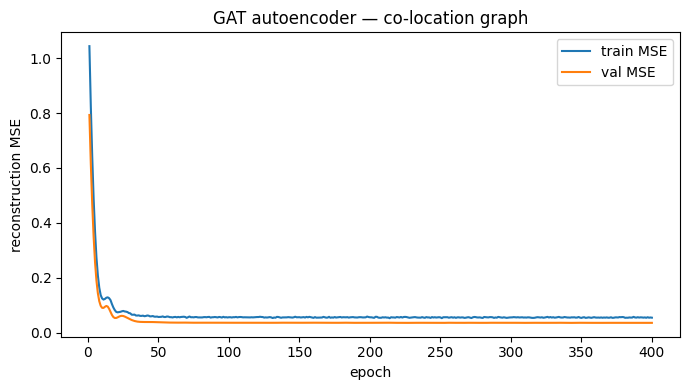

In [23]:
if not GAT_CACHE_HIT:
    h = np.array([(e, tr, va) for e, tr, va in hist_coloc])
    plt.figure(figsize=(7, 4))
    plt.plot(h[:, 0], h[:, 1], label="train MSE")
    plt.plot(h[:, 0], h[:, 2], label="val MSE")
    plt.xlabel("epoch"); plt.ylabel("reconstruction MSE")
    plt.title("GAT autoencoder — co-location graph"); plt.legend(); plt.tight_layout()
    plt.show()
else:
    print("[SKIPPED - using GAT weight checkpoint] loss-curve plot: hist_coloc is not stored in the "
          "GAT weight checkpoint (only final_reconstruction_mse is), so no curve is available to plot "
          "on a cache hit. Not fabricated.")

In [24]:
def export_weights(model, graph, nodes_df, path):
    model.eval()
    g = graph.to(DEVICE)
    with torch.no_grad():
        z, att_ei, att_w = model.encode(g.x, g.edge_index, return_attention=True)
        x_hat, _ = model(g.x, g.edge_index)
        recon = F.mse_loss(x_hat, g.x).item()
    emb = z.cpu()
    # per-site attention received = mean incoming attention weight (a scalar "importance" per site)
    att_ei = att_ei.cpu(); att_w = att_w.cpu().mean(dim=1) if att_w.dim() > 1 else att_w.cpu()
    dst = att_ei[1]
    recv = torch.zeros(g.num_nodes)
    cnt = torch.zeros(g.num_nodes)
    recv.index_add_(0, dst, att_w.float()); cnt.index_add_(0, dst, torch.ones_like(att_w.float()))
    site_attention = torch.where(cnt > 0, recv / cnt, torch.zeros_like(recv))
    payload = {
        "site_id": g.site_id.cpu(),
        "node_features_used": FEATURES,
        "embeddings": emb,                       # (N, emb_dim) per-site embedding
        "site_attention_received": site_attention,  # (N,) per-site attention weight
        "attention_edge_index": att_ei,          # (2, E') incl. self-loops added by GATConv
        "attention_edge_weight": att_w,          # (E',) mean-over-heads attention
        "final_reconstruction_mse": recon,
        "emb_dim": model.emb_dim, "epochs": EPOCHS, "seed": SEED,
        "note": "Embeddings are a spatial-co-location-prior representation, NOT a physical model.",
    }
    torch.save(payload, path)
    # convenience CSV
    csv = pd.DataFrame(emb.numpy(), columns=[f"emb_{i}" for i in range(emb.shape[1])])
    csv.insert(0, "site_id", g.site_id.cpu().numpy())
    csv["site_attention_received"] = site_attention.numpy()
    csv.to_csv(path.replace(".pt", ".csv"), index=False)
    return recon, emb.shape

if not GAT_CACHE_HIT:
    p_coloc = os.path.join(WORK, "gat_weights_colocation.pt")
    recon_c, shp_c = export_weights(model_coloc, g_coloc, nodes, p_coloc)
    print(f"Saved {p_coloc}  | embeddings {tuple(shp_c)} | final recon MSE {recon_c:.5f}")
    print(f"Also wrote {p_coloc.replace('.pt', '.csv')} (embeddings as CSV).")
    gat_payload_coloc = torch.load(p_coloc, weights_only=False)
    ckpt_save(gat_payload_coloc, "gat_weights_colocation", "torch", stage="A.1 GAT",
             staleness_keys=_gat_staleness)
else:
    recon_c = gat_payload_coloc["final_reconstruction_mse"]
    shp_c = tuple(gat_payload_coloc["embeddings"].shape)
    print(f"[SKIPPED - using GAT weight checkpoint] co-location export | embeddings {shp_c} | "
          f"cached recon MSE {recon_c:.5f}")

Saved C:\Users\gauri\Projects\nexus\outputs_v2\partA\gat_weights_colocation.pt  | embeddings (4889, 8) | final recon MSE 0.03446
Also wrote C:\Users\gauri\Projects\nexus\outputs_v2\partA\gat_weights_colocation.csv (embeddings as CSV).
[CKPT SAVE] gat_weights_colocation (torch) -> C:\Users\gauri\Projects\nexus\outputs_v2\partA\checkpoints\gat_weights_colocation__v1.pt  |  1,641,642 bytes  |  torch object


In [25]:

if not GAT_CACHE_HIT:
    print("Training GAT autoencoder on the RANDOM-CONTROL graph:")
    model_rand, hist_rand = train_gat(g_rand, epochs=EPOCHS, tag="random")
    final_train_r = hist_rand[-1][1]; final_val_r = hist_rand[-1][2]
    print(f"\nRANDOM-CONTROL final: epochs={EPOCHS}, train MSE={final_train_r:.5f}, val MSE={final_val_r:.5f}")

    p_rand = os.path.join(WORK, "gat_weights_random_control.pt")
    recon_r, shp_r = export_weights(model_rand, g_rand, nodes, p_rand)
    print(f"Saved {p_rand}  | embeddings {tuple(shp_r)} | final recon MSE {recon_r:.5f}")
    gat_payload_random = torch.load(p_rand, weights_only=False)
    ckpt_save(gat_payload_random, "gat_weights_random", "torch", stage="A.1 GAT",
             staleness_keys=_gat_staleness)
else:
    final_train_r = final_val_r = float("nan")  # not stored in the GAT weight checkpoint
    recon_r = gat_payload_random["final_reconstruction_mse"]
    shp_r = tuple(gat_payload_random["embeddings"].shape)
    print(f"[SKIPPED - using GAT weight checkpoint] random-control training+export | "
          f"embeddings {shp_r} | cached recon MSE {recon_r:.5f} "
          "(train/val MSE curve not cached -> NaN, not fabricated)")

Training GAT autoencoder on the RANDOM-CONTROL graph:
  [random] epoch    1 | train MSE 1.04174 | val MSE 0.97078


  [random] epoch   50 | train MSE 0.57799 | val MSE 0.50377


  [random] epoch  100 | train MSE 0.56069 | val MSE 0.49229


  [random] epoch  150 | train MSE 0.54851 | val MSE 0.48488


  [random] epoch  200 | train MSE 0.53829 | val MSE 0.48175


  [random] epoch  250 | train MSE 0.53781 | val MSE 0.47776


  [random] epoch  300 | train MSE 0.53911 | val MSE 0.47608


  [random] epoch  350 | train MSE 0.53804 | val MSE 0.47515


  [random] epoch  400 | train MSE 0.53364 | val MSE 0.47593

RANDOM-CONTROL final: epochs=400, train MSE=0.53364, val MSE=0.47593
Saved C:\Users\gauri\Projects\nexus\outputs_v2\partA\gat_weights_random_control.pt  | embeddings (4889, 8) | final recon MSE 0.46855
[CKPT SAVE] gat_weights_random (torch) -> C:\Users\gauri\Projects\nexus\outputs_v2\partA\checkpoints\gat_weights_random__v1.pt  |  1,641,598 bytes  |  torch object


In [26]:
print("================ CO-LOCATION vs RANDOM-CONTROL (numbers only) ================")
print(f"  final train MSE : co-location {final_train_c:.5f}  |  random {final_train_r:.5f}")
print(f"  final val   MSE : co-location {final_val_c:.5f}  |  random {final_val_r:.5f}")
print(f"  full recon MSE  : co-location {recon_c:.5f}  |  random {recon_r:.5f}")
better = "co-location" if recon_c < recon_r else "random-control"
print(f"  lower reconstruction error: {better}")


================ CO-LOCATION vs RANDOM-CONTROL (numbers only) ================
  final train MSE : co-location 0.05423  |  random 0.53364
  final val   MSE : co-location 0.03540  |  random 0.47593
  full recon MSE  : co-location 0.03446  |  random 0.46855
  lower reconstruction error: co-location


In [27]:
section("A.2 -- checkpoint manifest")

manifest_df = pd.DataFrame(CKPT_MANIFEST)
manifest_path = os.path.join(WORK, "checkpoint_manifest.csv")
if len(manifest_df):
    manifest_df.to_csv(manifest_path, index=False)
    print(f"Wrote {manifest_path} ({len(manifest_df)} rows).")
    display(manifest_df)
else:
    print("No checkpoint activity recorded this run (CKPT_MANIFEST empty) -- nothing to write.")



A.2 -- checkpoint manifest
Wrote C:\Users\gauri\Projects\nexus\outputs_v2\partA\checkpoint_manifest.csv (7 rows).


,stage,name,kind,path,bytes,rows_or_shape,hit_or_miss
0,A.1 temperature,temperature_snapshot,csv,C:\Users\gauri\Projects\nexus\outputs_v2\partA...,214272,4889 rows,MISS (just saved)
1,A.1 alignment,aligned_dataset,parquet,C:\Users\gauri\Projects\nexus\outputs_v2\partA...,314481,6131 rows,MISS (just saved)
2,A.1 graph,graph_colocation,torch,C:\Users\gauri\Projects\nexus\outputs_v2\partA...,1450792,torch object,MISS (just saved)
3,A.1 graph,graph_random_control,torch,C:\Users\gauri\Projects\nexus\outputs_v2\partA...,1450900,torch object,MISS (just saved)
4,A.1 graph,graph_nodes,parquet,C:\Users\gauri\Projects\nexus\outputs_v2\partA...,277615,4889 rows,MISS (just saved)
5,A.1 GAT,gat_weights_colocation,torch,C:\Users\gauri\Projects\nexus\outputs_v2\partA...,1641642,torch object,MISS (just saved)
6,A.1 GAT,gat_weights_random,torch,C:\Users\gauri\Projects\nexus\outputs_v2\partA...,1641598,torch object,MISS (just saved)
